<h1>Project 1: Data Analysis Project<h1>

<h2> 1 Inequality in Denmark

### 1.1 The Gini coefficient and the top 10 percent share

In [1]:
%pip install git+https://github.com/alemartinello/dstapi
%pip install fredapi

  Cloning https://github.com/alemartinello/dstapi to C:\Users\mathi\AppData\Local\Temp\pip-req-build-tv5z130k
  Resolved https://github.com/alemartinello/dstapi to commit d9eeb5a82cbc70b7d63b2ff44d92632fd77123a4
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/alemartinello/dstapi 'C:\Users\mathi\AppData\Local\Temp\pip-req-build-tv5z130k'


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dstapi import DstApi
import pandas as pd

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})


In [3]:
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')


Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [4]:
IFOR41.variable_levels('ULLIG',language='en') ##might not be necessary

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [5]:
params = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

ginidk = IFOR41.get_data(params=params)
ginidk.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


In [6]:
ginidk=ginidk.drop(columns=['ULLIG','KOMMUNEDK'])
ginidk = ginidk.rename(columns={'INDHOLD':'gini', 'TID': 'year'})
ginidk= ginidk.set_index('year').sort_index()

ginidk.head(5)

,gini
year,
1987,22.07
1988,22.06
1989,21.93
1990,22.16
1991,21.99


Text(0, 0.5, 'Gini')

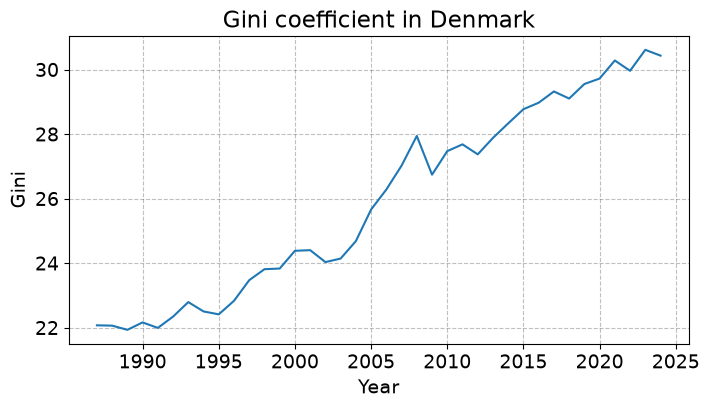

In [7]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot()
ax.plot(ginidk.index,ginidk['gini'].astype(float))
ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini')

In [8]:
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [9]:
params = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

df = IFOR32.get_data(params=params)
df.head(10)
df.tail(10)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
370,First decil,All Denmark,2001,62629
371,Second decil,All Denmark,2001,98552
372,Third decil,All Denmark,2001,114430
373,Fourth decil,All Denmark,2001,129885
374,Fifth decil,All Denmark,2001,144273
375,Sixth decil,All Denmark,2001,158392
376,Seventh decil,All Denmark,2001,173884
377,Eigth decil,All Denmark,2001,193021
378,Ninth decil,All Denmark,2001,221638
379,Tenth decil,All Denmark,2001,338942


In [10]:
df=df.drop(columns=['KOMMUNEDK'])
df = df.rename(columns={'INDHOLD':'income', 'TID': 'year'})
df= df.set_index('year').sort_index()

df.head(5)

,DECILGEN,income
year,,
1987,Third decil,68786
1987,Fourth decil,77577
1987,Fifth decil,85361
1987,Sixth decil,92777
1987,Seventh decil,100691


<Axes: title={'center': 'Top 10% income share in Denmark'}, xlabel='Year', ylabel='Share of total income'>

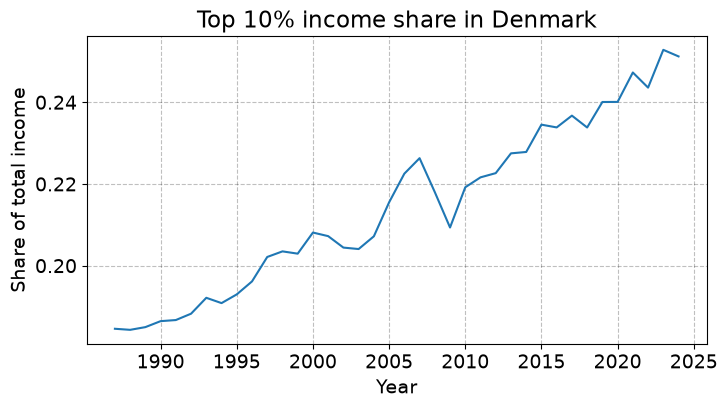

In [11]:
pivot = df.pivot_table(values='income', index=df.index, columns='DECILGEN', aggfunc='sum')
top10_share = pivot['Tenth decil'] / pivot.sum(axis=1)

top10_share.plot(title='Top 10% income share in Denmark', ylabel='Share of total income', xlabel='Year', figsize=(8,4))

#Describe how inequality in Denmark has developed since 1987. Do the two measures
tell the same story? 

Both graphs show gradually increasing inequality from 1987 to 2000, a slight dip from 2000 to ~2003 followed by a sharp spike that peaked immediately before the financial crisis and sharply fell during it, before continuing on its previous trend of gradually increasing from 2010-2024.


In [12]:
#Compute the correlation between them over time
np.corrcoef(ginidk['gini'].astype(float), top10_share)[0,1]



np.float64(0.9816415450527721)

### 1.2 Prediction

In [13]:
# Importing the packages

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [14]:
# Setting up the prediction

y= ginidk['gini'].astype(float).values
t = ginidk.index.astype(int).values - 1987
t = t.astype(float)

S1 = lambda beta: sum((y-(beta[0] + beta[1]*t))**2)
S2 = lambda beta: sum((y-(beta[0] + beta[1]*t+beta[2]*t**2))**2)


In [15]:
# Solving the minimization problem

minproblin= minimize(S1, x0=(0,0), constraints=None)
minprobqua= minimize(S2, x0=(0,0,0), constraints=None)

beta0_lin, beta1_lin = minproblin.x
beta0_quad, beta1_quad, beta2_quad = minprobqua.x

print("beta linear=", beta0_lin, beta1_lin)
print("beta quadratic=", beta0_quad, beta1_quad, beta2_quad)

beta linear= 21.042753545648125 0.26354959467635763
beta quadratic= 21.304194481547334 0.2199755024385422 0.0011776765796633012


In [16]:
# Checking the answes against np.polyfit

coeff_lin = np.polyfit(t,y,1)
print(coeff_lin)

coeff_quad= np.polyfit(t,y,2)
print(coeff_quad)

[ 0.26354962 21.04275304]
[1.17769085e-03 2.19975061e-01 2.13042004e+01]


Text(0, 0.5, 'Gini')

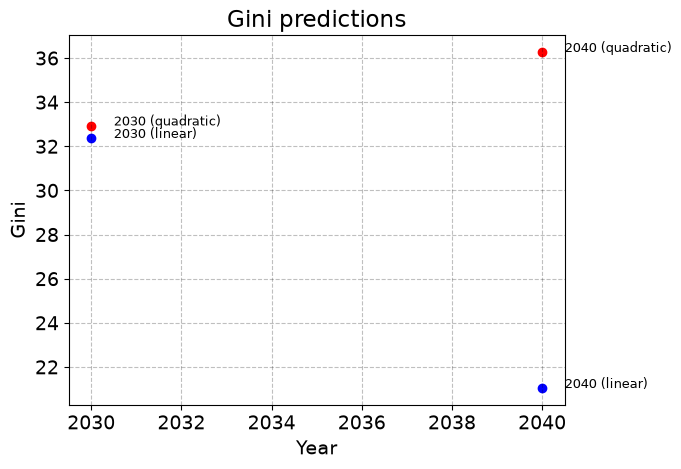

In [17]:
# Predicting and plotting the Gini coefficient in 2030 and 2040
t2030=2030-1987
t2040=2040-1987

"""
To find y, I set y to the formula S1 and S2 because the difference between them should be 0 if the formula is correctly minimized.
"""
lin_gin2030 = beta0_lin + beta1_lin*t2030
lin_gin2040 = beta0_lin + beta1_lin**t2040
quad_gin2030= beta0_quad + beta1_quad*t2030+beta2_quad*t2030**2
quad_gin2040= beta0_quad + beta1_quad*t2040+beta2_quad*t2040**2

plt.scatter(2030, lin_gin2030, color='blue')
plt.text(2030 + 0.5, lin_gin2030 + 0.001, '2030 (linear)', fontsize=9)

plt.scatter(2040, lin_gin2040, color='blue')
plt.text(2040 + 0.5, lin_gin2040 + 0.001, '2040 (linear)', fontsize=9)

plt.scatter(2030, quad_gin2030, color='red')
plt.text(2030 + 0.5, quad_gin2030 + 0.001, '2030 (quadratic)', fontsize=9)

plt.scatter(2040, quad_gin2040, color='red')
plt.text(2040 + 0.5, quad_gin2040 + 0.001, '2040 (quadratic)', fontsize=9)

plt.title('Gini predictions')
plt.xlabel('Year')
plt.ylabel('Gini')

The plot shows linear and quadratic predictions of the gini coefficient for 20230 and 2040. In 2030 we see that the two predictions are prette close to each other. In 2040 there is a pretty big difference between the linear and quadratic gini prediction. We see a difference in precicted gini coefficient at around 15. This shows that the predictions rely highly to the choice of model. The gini coefficient in Denmark has increased in the last centuries. Therefore, its easy to believe that this development in gini will continue. However, I would not trust the model to predict the gini coefficient, as they are both simple models based on the trend and doesnt include all the factors which actually drives the change in the gini coeffiecient such as policy, enplyment and demographics.

### 1.3 Municipalities

#### 1.3.1

In [18]:
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [19]:
#Gini across municipalities

params_muni_gini = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

municip_gini = IFOR41.get_data(params=params_muni_gini)
municip_gini.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,Copenhagen,2016,33.24
2,Gini coefficient,Frederiksberg,2016,34.85
3,Gini coefficient,Ballerup,2016,25.77
4,Gini coefficient,Brøndby,2016,25.71


In [20]:
# Clearing the data

municip_gini=municip_gini.drop(columns=['ULLIG',])
municip_gini = municip_gini.rename(columns={'INDHOLD':'gini', 'TID': 'year','KOMMUNEDK':'municipalities'})
municip_gini= municip_gini.set_index('year').sort_index()

display(municip_gini)

,municipalities,gini
year,,
1987,Læsø,22.81
1987,Vesthimmerlands,21.75
1987,Frederikshavn,20.35
1987,Brønderslev,21.51
1987,Viborg,20.69
...,...,...
2024,Ringkøbing-Skjern,26.93
2024,Ikast-Brande,26.89
2024,Aarhus,33.43


In [21]:
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [22]:
# Top 10 share across municipalities

params_muni_top10 = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

municip_top10 = IFOR32.get_data(params=params_muni_top10)
display(municip_top10)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,Second decil,Odense,2013,123841
1,Third decil,Odense,2013,150153
2,Fourth decil,Odense,2013,170790
3,Fifth decil,Odense,2013,193979
4,Sixth decil,Odense,2013,218942
...,...,...,...,...
37615,Seventh decil,Nyborg,2017,260847
37616,Eigth decil,Nyborg,2017,290986
37617,Ninth decil,Nyborg,2017,335590
37618,Tenth decil,Nyborg,2017,500383


In [23]:
# Clearing the data

municip_top10 = municip_top10.rename(columns={'INDHOLD':'income', 'TID': 'year','KOMMUNEDK':'municipalities'})
municip_top10= municip_top10.set_index('year').sort_index()

municip_top10.head(5)

,DECILGEN,municipalities,income
year,,,
1987,Sixth decil,Vesthimmerlands,83991
1987,Fifth decil,Vesthimmerlands,77185
1987,Fourth decil,Vesthimmerlands,69840
1987,Third decil,Vesthimmerlands,62376
1987,Second decil,Vesthimmerlands,54003


In [24]:
municip_top10_reset = municip_top10.reset_index()

pivot_muni = municip_top10_reset.pivot_table(
    values='income',
    index=['year', 'municipalities'],
    columns='DECILGEN',
    aggfunc='sum'
)

municip_top10_share = pivot_muni['Tenth decil'] / pivot.sum(axis=1)

display(municip_top10_share)

year  municipalities 
1987  Aabenraa           0.174965
      Aalborg            0.170437
      Aarhus             0.180832
      Albertslund        0.176451
      All Denmark        0.184549
                           ...   
2024  Vejle              0.236771
      Vesthimmerlands    0.200238
      Viborg             0.208468
      Vordingborg        0.189599
      Ærø                0.176300
Length: 3762, dtype: float64

In [25]:
# Merging the two tables 

combined = pd.merge(
    municip_gini.reset_index(),
    municip_top10_share.reset_index(name='top10_share'),
    on=['year', 'municipalities'],
    how='inner'
)

combined = combined.sort_values(['municipalities', 'year']).reset_index(drop=True)

display(combined)

,year,municipalities,gini,top10_share
0,1987,Aabenraa,21.33,0.174965
1,1988,Aabenraa,21.51,0.174845
2,1989,Aabenraa,20.74,0.174342
3,1990,Aabenraa,20.83,0.175503
4,1991,Aabenraa,20.86,0.180219
...,...,...,...,...
3757,2020,Ærø,25.61,0.175799
3758,2021,Ærø,26.63,0.180296
3759,2022,Ærø,27.02,0.178989
3760,2023,Ærø,27.67,0.177187


In [26]:
# Setting the type

combined['gini'] = combined['gini'].astype(float)
combined['top10_share'] = combined['top10_share'].astype(float)

In [27]:
# Using groupby to find year-to-year differences

combined[['diff_gini','diff_top10_share']] = combined.groupby('municipalities')[['gini','top10_share']].diff()
combined.head(20)

,year,municipalities,gini,top10_share,diff_gini,diff_top10_share
0,1987,Aabenraa,21.33,0.174965,NaN,NaN
1,1988,Aabenraa,21.51,0.174845,0.18,-0.000121
2,1989,Aabenraa,20.74,0.174342,-0.77,-0.000503
3,1990,Aabenraa,20.83,0.175503,0.09,0.001161
4,1991,Aabenraa,20.86,0.180219,0.03,0.004716
5,1992,Aabenraa,20.96,0.180881,0.10,0.000662
6,1993,Aabenraa,21.57,0.187006,0.61,0.006124
7,1994,Aabenraa,21.22,0.188432,-0.35,0.001426
8,1995,Aabenraa,21.26,0.191632,0.04,0.003200
9,1996,Aabenraa,21.43,0.193367,0.17,0.001735


In [28]:
# Printing the mean of the correlation

corr=combined.groupby('municipalities')['diff_gini'].corr(combined['diff_top10_share']).rename('correlation')
mean_correlation=corr.mean()
print(f'{mean_correlation = :.3f}')

mean_correlation = 0.644


In [29]:
# Sorting the values

corr = corr.sort_values()
print(corr)

municipalities
Sønderborg     -0.059326
Brønderslev     0.213366
Assens          0.230789
Kalundborg      0.268913
Guldborgsund    0.292057
                  ...   
Egedal          0.934802
Solrød          0.942683
Vejen           0.967018
Fredensborg     0.974044
Billund         0.995300
Name: correlation, Length: 99, dtype: float64


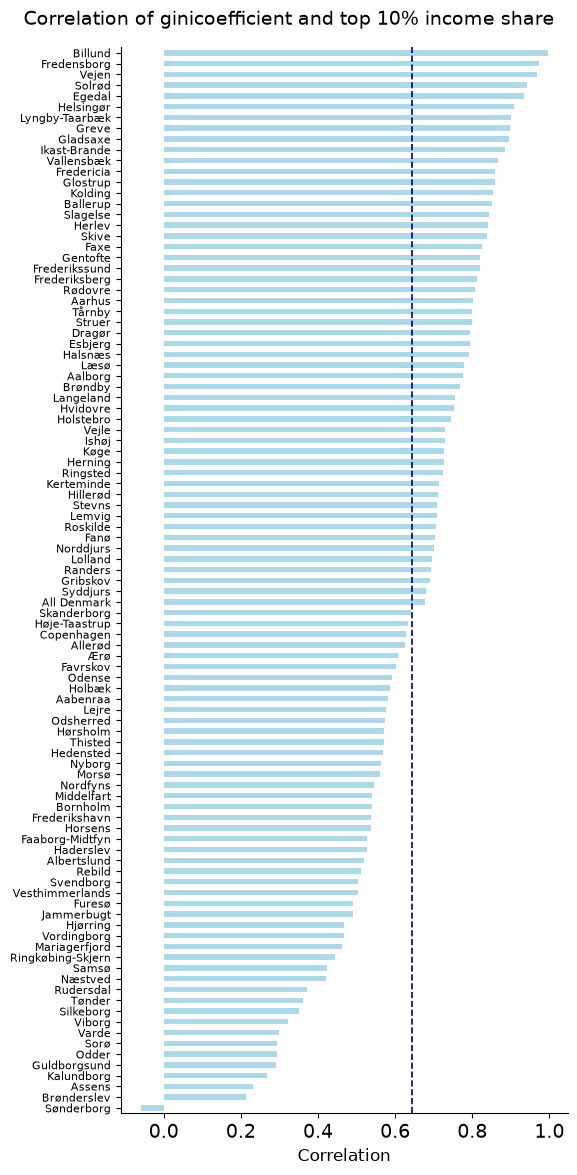

In [30]:
# Plotting the correlation

fig, ax = plt.subplots(figsize=(6, 12))

ax.barh(corr.index, corr.values,height=0.5, color='lightblue')


ax.axvline(mean_correlation,color='darkblue',linestyle='--',linewidth=1.2,label=f'Mean = {mean_correlation:.2f}')

ax.set_xlabel('Correlation',fontsize=12)

ax.set_yticks(range(len(corr.index)))
ax.set_yticks(np.arange(len(corr.index))*1)
ax.set_yticklabels(corr.index,fontsize=8)
ax.set_ylim(-0.5,len(corr.index)-0.5)


ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)


fig.suptitle('Correlation of ginicoefficient and top 10% income share',fontsize=14)
fig.tight_layout()

We see that the correlation between the gini coefficient and the top 10% income shares varies alot across the different municipalities. We see almost perfect correaltion in the municippalities Billund & Fredensborg. On the other hand, we also see municipalities with a very small correlation. The mean of the correlation is 0,644 which suggests a fairly strong overall link between the gini coefficient and the top 10% income shares. However, the risk of outliers driven by a few high income individuals the small municipalities is worth keeping in mind because it can skew the gini coefficient. Therefore, there is a risk of them bluring the correlation.

#### 1.3.2

In [31]:
#Sorting gini for 2024
gini_2024 = municip_gini.loc[2024].sort_values('gini')

#Finding the smallest and largest gini coefficients
smallest_gini = gini_2024[['municipalities', 'gini']].head(10)
largest_gini = gini_2024[['municipalities', 'gini']].tail(10)

print("10 most equal municipalities: ", smallest_gini)
print("10 most unequal municipalities: ", largest_gini)

10 most equal municipalities:         municipalities   gini
year                        
2024  Faaborg-Midtfyn  23.77
2024           Egedal  23.85
2024         Bornholm  24.03
2024             Faxe  24.09
2024         Favrskov  24.41
2024          Halsnæs  24.41
2024           Assens  24.46
2024        Hedensted  24.58
2024      Albertslund  24.66
2024            Odder  24.70
10 most unequal municipalities:        municipalities   gini
year                       
2024       Helsingør  30.55
2024     Fredensborg  32.76
2024          Aarhus  33.43
2024      Copenhagen  34.97
2024   Frederiksberg  36.54
2024  Lyngby-Taarbæk  39.28
2024        Hørsholm  40.07
2024           Vejen  46.32
2024       Rudersdal  47.31
2024        Gentofte  49.04


#### 1.3.3

In [32]:

municip_gini3 = municip_gini.reset_index()
gini_2024 = municip_gini3[municip_gini3['year'] == 2024][['municipalities', 'gini']].rename(columns={'gini': 'gini_2024'})
gini_1987 = municip_gini3[municip_gini3['year'] == 1987][['municipalities', 'gini']].rename(columns={'gini': 'gini_1987'})

gini_change = gini_2024.merge(gini_1987, on='municipalities', how='inner')


gini_change['gini_change'] = gini_change['gini_2024'].astype(float) - gini_change['gini_1987'].astype(float)

gini_change_sorted = gini_change.sort_values('gini_change', ascending=False)


# Biggest change
print("Biggest change in Gini: ", gini_change_sorted.head(10))

# Smallest change
print("Smallest change in Gini", gini_change.sort_values('gini_change', ascending=True).head(10))

Biggest change in Gini:      municipalities gini_2024 gini_1987  gini_change
23           Vejen     46.32     21.20        25.12
63       Rudersdal     47.31     29.05        18.26
49        Gentofte     49.04     31.10        17.94
51  Lyngby-Taarbæk     39.28     24.97        14.31
29      Copenhagen     34.97     23.05        11.92
31        Hørsholm     40.07     28.39        11.68
58     Fredensborg     32.76     21.17        11.59
96          Aarhus     33.43     22.10        11.33
62   Frederiksberg     36.54     25.28        11.26
55      Vallensbæk     26.70     15.90        10.80
Smallest change in Gini      municipalities gini_2024 gini_1987  gini_change
5              Fanø     26.34     25.67         0.67
27              Ærø     26.98     24.63         2.35
40             Faxe     24.09     21.64         2.45
67             Læsø     25.41     22.81         2.60
81         Bornholm     24.03     21.31         2.72
84  Faaborg-Midtfyn     23.77     20.88         2.89
75      

### 1.4 Extension

In [33]:
# Using table AULP01 for this task - importing the data

AULP01 = DstApi('AULP01') 

AULP01.tablesummary(language='en')

Table AULP01: Full-time unemployed persons in per cent of the labour force by region, age, sex and time
Last update: 2026-04-14T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,OMRÅDE,117,000,All Denmark,997,Abroad,False
1,ALDER,10,TOT,"Age, total",6099,60 year and over,False
2,KØN,3,TOT,Total,K,Women,False
3,Tid,19,2007,2007,2025,2025,True


In [34]:
# Setting up the table for AULP01

params = {
    'table': 'AULP01',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['*']},
        {'code': 'ALDER', 'values': ['TOT']},
        {'code': 'KØN', 'values': ['TOT']}, 
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

unemployment = AULP01.get_data(params=params)
unemployment.head(5)

,OMRÅDE,ALDER,KØN,TID,INDHOLD
0,All Denmark,"Age, total",Total,2013,5.8
1,Province Byen København,"Age, total",Total,2013,6.9
2,Province Københavns omegn,"Age, total",Total,2013,5.9
3,Province Nordsjælland,"Age, total",Total,2013,4.4
4,Province Bornholm,"Age, total",Total,2013,7.0


In [35]:
# Cleaning it up

unemployment=unemployment.drop(columns=['ALDER','KØN'])
unemployment = unemployment.rename(columns={'INDHOLD':'unemployment', 'OMRÅDE': 'municipality', 'TID': 'year'})
unemployment= unemployment.set_index('year').sort_index()

display(unemployment)

,municipality,unemployment
year,,
2007,Skive,2.4
2007,Hedensted,1.6
2007,Ringkøbing-Skjern,1.8
2007,Ikast-Brande,3.0
2007,Solrød,2.6
...,...,...
2025,Svendborg,2.9
2025,Odense,3.8
2025,Nyborg,3.2


In [36]:
# Sorting in alphabetic order

unemployment = unemployment.reset_index().sort_values(['year','municipality']).reset_index(drop=True) 
display(unemployment)

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
4,2007,All Denmark,3.6
...,...,...,...
2180,2025,Vejle,2.4
2181,2025,Vesthimmerlands,2.6
2182,2025,Viborg,2.5
2183,2025,Vordingborg,2.9


In [37]:
# Dropping rows

drop_rows = unemployment.municipality.str.contains('Region')
drop_rows  |= unemployment.municipality.str.contains('Province')
drop_rows |= unemployment.municipality.str.contains('All Denmark')
drop_rows |= unemployment.year==2025
unemployment.loc[~drop_rows,:]

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
5,2007,Allerød,1.6
...,...,...,...
2065,2024,Vejle,2.6
2066,2024,Vesthimmerlands,2.9
2067,2024,Viborg,2.7
2068,2024,Vordingborg,3.0


In [38]:
# Saving the result

unemployment= unemployment.loc[drop_rows==False] 
unemployment.iloc[:5,:5]

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
5,2007,Allerød,1.6


In [39]:
# Using table IFOR41 for the gini coefficient
# Resetting index to use for this task

municip_gini4 = municip_gini.reset_index()

display(municip_gini4)

,year,municipalities,gini
0,1987,Læsø,22.81
1,1987,Vesthimmerlands,21.75
2,1987,Frederikshavn,20.35
3,1987,Brønderslev,21.51
4,1987,Viborg,20.69
...,...,...,...
3757,2024,Ringkøbing-Skjern,26.93
3758,2024,Ikast-Brande,26.89
3759,2024,Aarhus,33.43
3760,2024,Skanderborg,25.01


In [40]:
# Dropping rows

drop_rows = municip_gini4.year.between(1987,2006)
drop_rows |= municip_gini4.municipalities.str.contains('All Denmark')
municip_gini5=municip_gini4.loc[~drop_rows,:]
display(municip_gini5)

,year,municipalities,gini
1980,2007,Lemvig,28.56
1981,2007,Syddjurs,28.06
1982,2007,Struer,23.29
1983,2007,Hjørring,24.88
1984,2007,Aalborg,26.07
...,...,...,...
3757,2024,Ringkøbing-Skjern,26.93
3758,2024,Ikast-Brande,26.89
3759,2024,Aarhus,33.43
3760,2024,Skanderborg,25.01


In [41]:
# Merging the two tables

unemployment2 = unemployment.rename(columns={'municipality': 'municipalities'})

combined1 = pd.merge(
    unemployment2.reset_index(drop=True),
    municip_gini5.reset_index(drop=True),
    on=['year', 'municipalities'],
    how='inner'
)

combined1 = combined1.sort_values(['municipalities', 'year']).reset_index(drop=True)

display(combined1)

,year,municipalities,unemployment,gini
0,2007,Aabenraa,3.8,25.36
1,2008,Aabenraa,2.8,26.88
2,2009,Aabenraa,5.2,25.57
3,2010,Aabenraa,6.8,25.09
4,2011,Aabenraa,6.4,25.01
...,...,...,...,...
1759,2020,Ærø,4.0,25.61
1760,2021,Ærø,3.1,26.63
1761,2022,Ærø,1.8,27.02
1762,2023,Ærø,1.9,27.67


In [42]:
# Setting the type

combined1['unemployment'] = combined1['unemployment'].astype(float)
combined1['gini'] = combined1['gini'].astype(float)

In [43]:
# Using groupby to find year-to-year differences

combined1[['diff_unemployment','diff_gini']] = combined1.groupby('municipalities')[['unemployment','gini']].diff()
combined1.head(20)

,year,municipalities,unemployment,gini,diff_unemployment,diff_gini
0,2007,Aabenraa,3.8,25.36,NaN,NaN
1,2008,Aabenraa,2.8,26.88,-1.0,1.52
2,2009,Aabenraa,5.2,25.57,2.4,-1.31
3,2010,Aabenraa,6.8,25.09,1.6,-0.48
4,2011,Aabenraa,6.4,25.01,-0.4,-0.08
5,2012,Aabenraa,6.9,24.83,0.5,-0.18
6,2013,Aabenraa,6.4,25.36,-0.5,0.53
7,2014,Aabenraa,5.2,27.42,-1.2,2.06
8,2015,Aabenraa,4.7,25.27,-0.5,-2.15
9,2016,Aabenraa,4.0,25.38,-0.7,0.11


In [44]:
# Printing the mean of the correlation

corr1=combined1.groupby('municipalities')['diff_unemployment'].corr(combined1['diff_gini']).rename('correlation1')
mean_correlation1=corr1.mean()
print(f'{mean_correlation1 = :.3f}')

mean_correlation1 = -0.198


In [45]:
# Sorting the values

corr1 = corr1.sort_values()
print(corr1)

municipalities
Kalundborg    -0.725965
Rebild        -0.693818
Norddjurs     -0.681937
Brønderslev   -0.656554
Assens        -0.644497
                 ...   
Læsø           0.301239
Brøndby        0.372060
Glostrup       0.524221
Hvidovre       0.598075
Albertslund    0.824240
Name: correlation1, Length: 98, dtype: float64


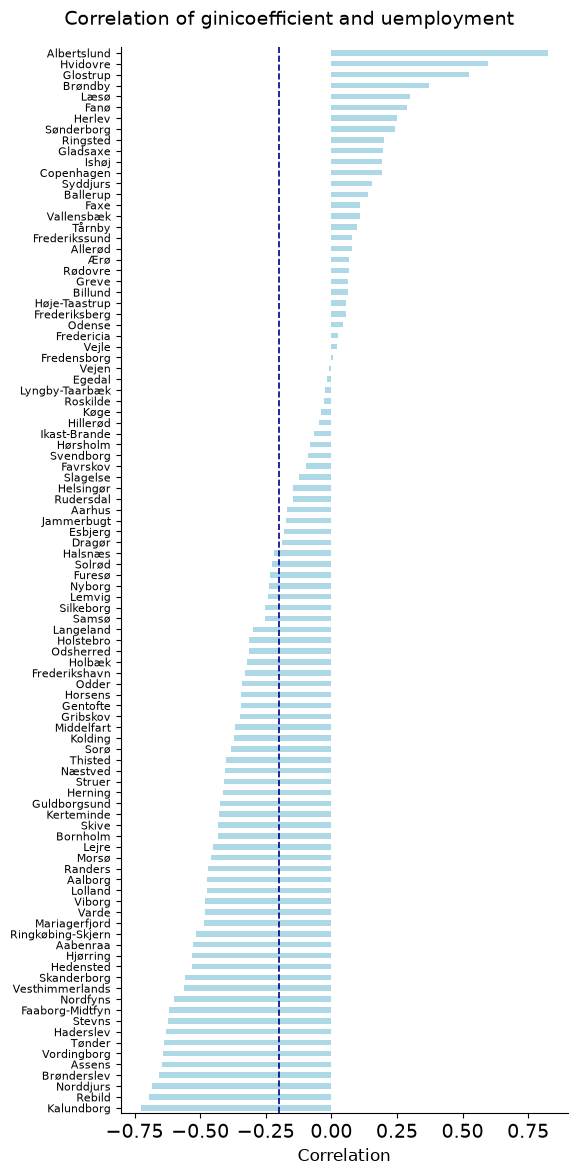

In [46]:
# Plotting the correlation

fig, ax = plt.subplots(figsize=(6, 12))

ax.barh(corr1.index, corr1.values,height=0.5, color='lightblue')


ax.axvline(mean_correlation1,color='darkblue',linestyle='--',linewidth=1.2,label=f'Mean = {mean_correlation1:.2f}')

ax.set_xlabel('Correlation',fontsize=12)

ax.set_yticks(range(len(corr1.index)))
ax.set_yticks(np.arange(len(corr1.index))*1)
ax.set_yticklabels(corr1.index,fontsize=8)
ax.set_ylim(-0.5,len(corr1.index)-0.5)


ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)


fig.suptitle('Correlation of ginicoefficient and uemployment',fontsize=14)
fig.tight_layout()

The chart shows the correlation between the gini coefficient ant unemployment divided into the danish munitipalities. Most municipalities shows a negative correlation. Howeever, about a third of the municipalities show a possitive correlation. The mean of the correlation -0.198 which indicate a small negative correlation.

<h2> 2 Simulating the income distribution

### 2.1 The model

In [47]:
import pickle
import numpy as np

from scipy.stats import norm 

In [48]:
from income_simulation import simulate_income_distribution
from Gini import gini


N=50000
p_e=(0.4,0.35,0.25)
s_e=(1,3,5)
h_e0=(1.00,1.20,1.55)
delta_e=(0.010,0.020,0.030)
delta=(0.06)
sigma_psi=0.1
lambda_psi=0.6
sigma=0.05
y_su=0.45
rho=0.60
y_floor=0.35
age_min=18
age_max=65
seed=123

result = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)


ages = result['ages']
income = result['income']      
employed = result['employed']
e = result['education']

print(result) ##need to make prettier

#Check that the mean is one for the lognormal shock psi
rng_check = np.random.default_rng(seed)
psi_check = rng_check.lognormal(-0.5 * sigma_psi**2, sigma_psi, size=1_000_000)

print(f'Mean of psi: {psi_check.mean():.4f}')  # should be equal or close to 1.0

{'ages': array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]), 'income': array([[0.45      , 0.45      , 0.45      , ..., 0.78061543, 0.75954873,
        0.8253255 ],
       [0.45      , 0.35      , 0.83498012, ..., 0.42095175, 0.43441942,
        0.42650798],
       [0.45      , 0.35      , 0.35      , ..., 0.7605678 , 0.92393649,
        1.05218231],
       ...,
       [0.45      , 0.45      , 0.45      , ..., 2.51647246, 2.07051497,
        2.00609383],
       [0.45      , 0.45      , 0.45      , ..., 2.44713031, 2.71745258,
        2.88679451],
       [0.45      , 0.35      , 1.09286273, ..., 2.81507515, 3.18277143,
        2.88798228]], shape=(50000, 48)), 'employed': array([[False, False, False, ...,  True,  True,  True],
       [False, False,  True, ...,  True,  True,  True],
       [False, False, False, ...,  True,  Tru

### 2.2 Simulate the income distribution

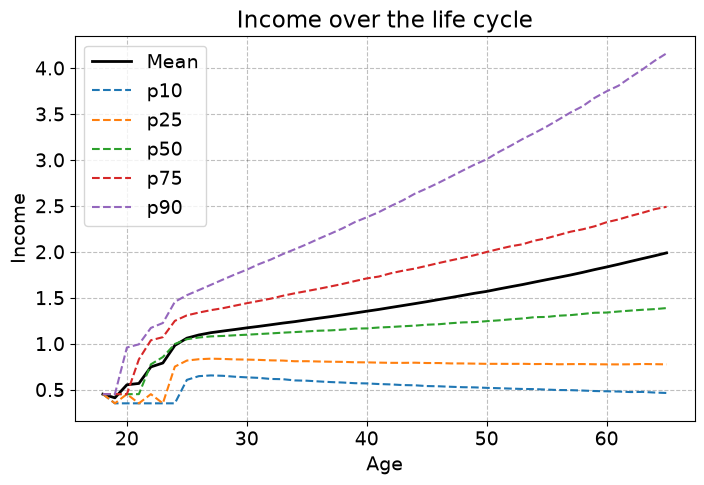

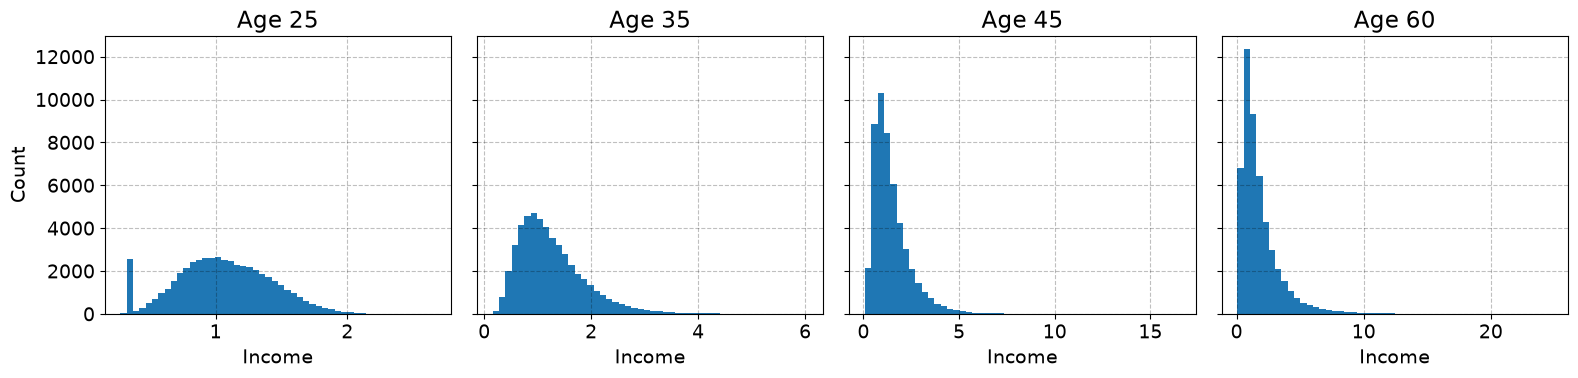

In [49]:

# Mean and selected percentiles of income over the life cycle

percentiles = [10, 25, 50, 75, 90]
income_percentiles = np.percentile(income, percentiles, axis=0)  # shape (5, T)
income_mean = income.mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ages, income_mean, label='Mean', linewidth=2, color='black')
for p, series in zip(percentiles, income_percentiles):
    ax.plot(ages, series, label=f'p{p}', linestyle='--')
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_title('Income over the life cycle')
ax.legend()
plt.show()

# Histograms of the income distribution at selected ages
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, age in zip(axes, [25, 35, 45, 60]):
    idx = age - age_min  # column index for this age
    ax.hist(income[:, idx], bins=50)
    ax.set_title(f'Age {age}')
    ax.set_xlabel('Income')
axes[0].set_ylabel('Count')
fig.tight_layout()
plt.show()



### 2.3 Compute the Gini coefficient

### 2.4 What drives inequality?

#### No education inequality
The inequality if everyone get´s a short education:

The Gini coefficient for all ages pooled is: 0.2955636357548794


C:\Users\mathi\AppData\Local\Temp\ipykernel_30080\2366366852.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


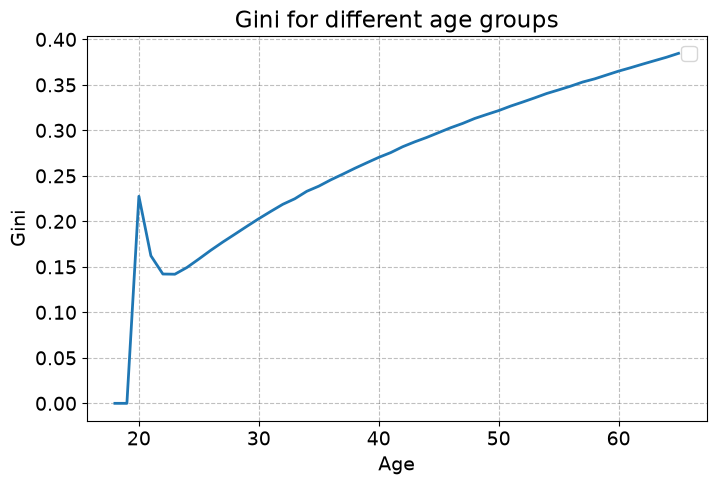

In [65]:
from Gini import gini

result_no_education_inequality = simulate_income_distribution(N, (1.0,0.0,0.0), s_e, h_e0, delta_e, delta, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_no_education_inequality = result_no_education_inequality['income']

def unwrap(x):
    unwraped= []
    for array in x:
        for element in array:
            unwraped.append(element)
    return unwraped

def incomeAtAge(income, age):
    atAge= []
    for array in income:
       atAge.append(array[age-age_min])
    return atAge


print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_no_education_inequality)))

def Gini_aged (switched_off_income):
    agedGini = []
    for age in ages:
        agedGini.append(gini(incomeAtAge(switched_off_income, age)))

    #Plotting "Gini for different age groups"
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ages, agedGini, linewidth=2)
    ax.set_xlabel('Age')
    ax.set_ylabel('Gini')
    ax.set_title('Gini for different age groups')
    ax.legend()
    plt.show()

Gini_aged(income_no_education_inequality)

#### No shock to human capital

The Gini coefficient for all ages pooled is: 0.2736059135148775


C:\Users\mathi\AppData\Local\Temp\ipykernel_30080\2366366852.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


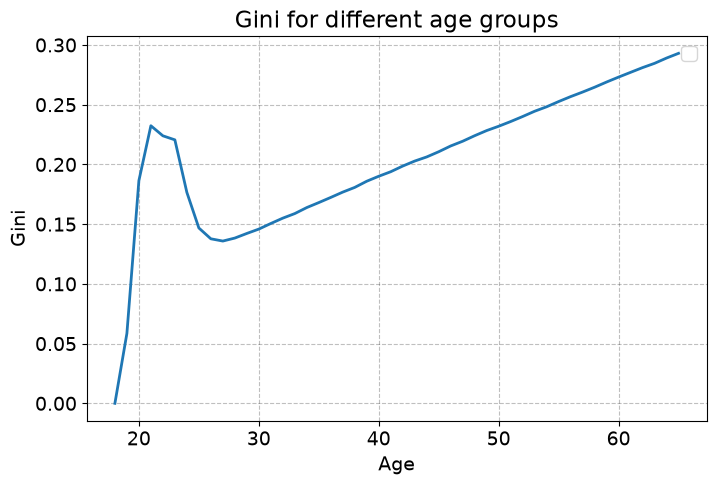

In [66]:
result_no_shock = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, 0.0,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_no_shock = result_no_shock['income']

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_no_shock)))

Gini_aged(income_no_shock)

#### Depreciation of human capital while unemployed

The Gini coefficient for all ages pooled is: 0.37980741075126667


C:\Users\mathi\AppData\Local\Temp\ipykernel_30080\2366366852.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


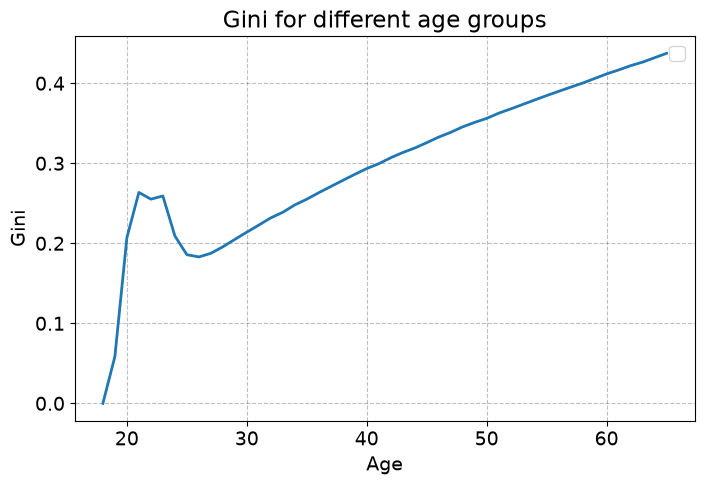

In [67]:
result_human_capital = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, 0.0, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_human_capital = result_human_capital['income']

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_human_capital)))

Gini_aged(income_human_capital)

#### Unemplyment itself

The Gini coefficient for all ages pooled is: 0.37685512511680463


C:\Users\mathi\AppData\Local\Temp\ipykernel_30080\2366366852.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


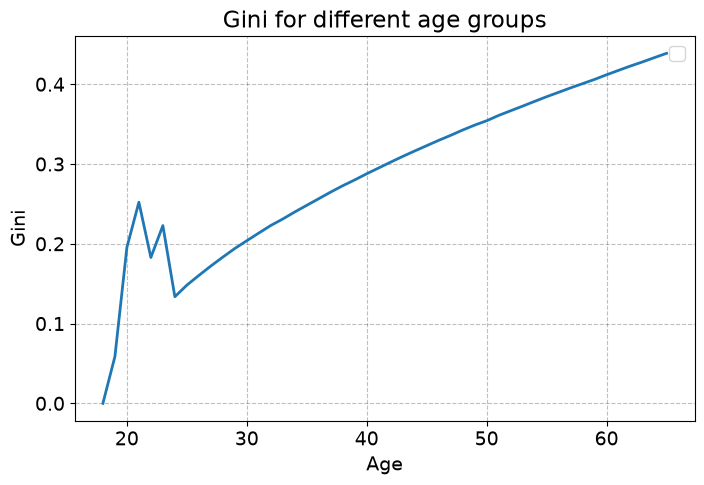

In [68]:
result_unemployment = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      1.0, 0.0, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_unemployment = result_unemployment['income']

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_unemployment)))

Gini_aged(income_unemployment)

### 2.5 Extension: more risk